# 02 — Baseline ANN

Detta notebook bygger och utvärderar en **baseline Artificial Neural Network (ANN)**
för att klassificera vinkvalitet som **god (1)** eller **dålig (0)**.

## Mål med detta notebook
- Ladda och förbehandla data via `src/data_preprocessing.py` (DRY — ingen dubblerad logik)
- Bygga en enkel ANN med 2 dolda lager (ReLU-aktivering, sigmoid output)
- Träna modellen och utvärdera med accuracy, confusion matrix och classification report
- Spara resultat som referenspunkt (baseline) inför Grid Search-optimering i steg 4

## Data
- Källa: `data/raw/WineQT.csv`
- Split: 70% train / 15% validation / 15% test (stratifierad på target)
- Skalning: `StandardScaler`, anpassad enbart på träningsdata

## Reproducerbarhet
`RANDOM_SEED = 42` används genomgående för konsekventa resultat.

In [1]:
# ── Imports ──────────────────────────────────────────────
import sys
import os

# Lägg till projektroten i sys.path så vi kan importera från src/
sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from src.data_preprocessing import load_data, preprocess

# ── Konfiguration ────────────────────────────────────────
RANDOM_SEED = 42
RAW_DATA_PATH = "../data/raw/WineQT.csv"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Kommentar till output

Cellen ovan importerar alla bibliotek som behövs för notebooken samt
`load_data` och `preprocess` från `src/data_preprocessing.py`.

`RANDOM_SEED = 42` sätts för både NumPy och TensorFlow, vilket säkerställer
att resultaten (vikt-initialisering, train/val/test-split, m.m.) blir
reproducerbara mellan körningar.

Utskriften visar vilken TensorFlow-version som används (förväntat: `2.19.0`).

> **Notis om gulmarkering:** Eventuell gul varning på `keras`-importen
> (`from tensorflow import keras`) är endast en lint-varning från
> Pylance/VS Code och påverkar inte funktionaliteten.

In [2]:
# ── Ladda och förbehandla data ────────────────────────────
# load_data(): läser in CSV, skapar binär label, droppar dubletter/Id,
#               och returnerar stratifierad train/val/test-split
print("Laddar och delar upp data...")
X_train, X_val, X_test, y_train, y_val, y_test = load_data(RAW_DATA_PATH)

print()

# preprocess(): skalar features med StandardScaler (fit på train, transform på alla)
print("Skalar features...")
X_train_scaled, X_val_scaled, X_test_scaled = preprocess(X_train, X_val, X_test)

Laddar och delar upp data...
   Loaded  : 1,143 rows × 13 columns
   Dropped column     : Id
   Duplicates removed : 125
   Class distribution : 546 good (1) | 472 poor (0)
   Train : 712 samples
   Val   : 153 samples
   Test  : 153 samples

Skalar features...
   Scaler fitted on 712 training samples
   Features scaled : 11


## Kommentar till output

`load_data()` läser in `WineQT.csv` (1 143 rader), droppar `Id`-kolumnen och
tar därefter bort **125 dubblettrader** (identiska fysikalisk-kemiska profiler)
— i linje med fynden från EDA (01_EDA.ipynb).

Kvar blir **1 018 unika prover**, vilka delas upp stratifierat på target:

| Split | Antal samples | Andel |
|-------|---------------|-------|
| Train | 712 | ~70% |
| Val   | 153 | ~15% |
| Test  | 153 | ~15% |

**Klassfördelning:** 546 god (1) / 472 dålig (0) — motsvarar ~53.6% / ~46.4%,
vilket bekräftar att klasserna är approximativt balanserade (ingen särskild
hantering av klassobalans krävs).

`preprocess()` skalar samtliga 11 features med `StandardScaler`, anpassad
**enbart på träningsdatan** (712 samples) och därefter använd för att
transformera val- och testdata — detta förhindrar data leakage från
skalningssteget.

## Bygga baseline-modellen

Vi bygger en enkel ANN med **2 dolda lager utan regularisering** som
referenspunkt (baseline) inför Grid Search-optimeringen i steg 4, där en
regulariserad arkitektur (`build_model()` i `src/model.py`, med L2 och
Dropout) kommer jämföras mot denna baseline.

**Arkitektur (`build_baseline_model`):**

| Lager | Typ | Storlek | Aktivering |
|-------|-----|---------|------------|
| Input | — | 11 features | — |
| Hidden 1 | Dense | 16 neuroner | ReLU |
| Hidden 2 | Dense | 8 neuroner | ReLU |
| Output | Dense | 1 neuron | Sigmoid |

**Kompilering:**
- Optimizer: `Adam` (learning rate = 0.001)
- Loss: `binary_crossentropy`
- Metric: `accuracy`

Den mer avancerade arkitekturen (`build_model()`, med 64→32 neuroner, L2-
regularisering och Dropout) finns redan i `src/model.py` och återanvänds
oförändrad i steg 4.

In [3]:
# ── Bygg baseline-modellen ─────────────────────────────────
from src.model import build_baseline_model

INPUT_DIM = X_train_scaled.shape[1]  # Antal features = 11

model = build_baseline_model(input_dim=INPUT_DIM)
model.summary()

Model: "baseline_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

## Kommentar till output

`build_baseline_model()` skapar en sekventiell modell `baseline_ann` med
totalt **337 tränbara parametrar**, fördelat på tre lager:

| Lager | Output shape | Parametrar | Beräkning |
|-------|--------------|------------|-----------|
| `hidden_1` (Dense, 16, ReLU) | (None, 16) | 192 | 11×16 vikter + 16 bias |
| `hidden_2` (Dense, 8, ReLU) | (None, 8) | 136 | 16×8 vikter + 8 bias |
| `output` (Dense, 1, Sigmoid) | (None, 1) | 9 | 8×1 vikter + 1 bias |

Modellen är liten och innehåller ingen regularisering (ingen L2, ingen
Dropout) — vilket är avsiktligt för en baseline. Eventuell overfitting som
syns under träning blir ett konkret motiv för regularisering i steg 4.

## Träna baseline-modellen

Modellen tränas med följande upplägg:

- **Epochs (max):** 100 — en övre gräns för antal träningsiterationer
- **Batch size:** 32 — standardval för småskaliga tabulära dataset
- **EarlyStopping:** övervakar `val_loss`. Om valideringsförlusten inte
  förbättras under 10 på varandra följande epochs avbryts träningen, och
  de vikter som gav lägst `val_loss` återställs (`restore_best_weights=True`)

Detta upplägg är industristandard: det undviker både onödig träningstid och
overfitting, samtidigt som modellen tillåts konvergera om den fortsätter
förbättras.

In [4]:
# ── Träningskonfiguration ──────────────────────────────────
EPOCHS = 100          # Övre gräns för antal epochs
BATCH_SIZE = 32       # Standardval för småskaliga tabulära dataset

# ── EarlyStopping ──────────────────────────────────────────
# Avbryter träningen om val_loss inte förbättras under `patience` epochs,
# och återställer de vikter som gav lägst val_loss.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# ── Träna modellen ─────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5590 - loss: 0.6711 - val_accuracy: 0.6144 - val_loss: 0.6728
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6390 - loss: 0.6320 - val_accuracy: 0.6732 - val_loss: 0.6405
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6812 - loss: 0.6054 - val_accuracy: 0.7124 - val_loss: 0.6179
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6910 - loss: 0.5834 - val_accuracy: 0.6928 - val_loss: 0.5991
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7022 - loss: 0.5654 - val_accuracy: 0.6863 - val_loss: 0.5847
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7177 - loss: 0.5516 - val_accuracy: 0.6993 - val_loss: 0.5735
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7219 - loss: 0.5410 - val_accuracy: 0.7124 - val_loss: 0.5646
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7275 - loss: 0.5328 - val_accuracy: 0.7255 - v

## Kommentar till output

Träningen kördes i **92 epochs** (av maximalt 100) innan `EarlyStopping`
avbröt processen — `val_loss` hade då inte förbättrats på 10 epochs i rad.
De vikter som gav lägst `val_loss` (~0.473, runt epoch 82–84) återställdes
automatiskt (`restore_best_weights=True`).

**Slutgiltiga (bästa) värden:**

| Metric | Train | Validation |
|--------|-------|------------|
| Accuracy | ~0.81 | ~0.76 |
| Loss | ~0.42 | ~0.473 |

Träningsaccuracy fortsatte stiga (upp mot ~0.82), medan validation accuracy
planade ut runt ~0.76. Det indikerar en lätt begynnande overfitting mot
slutet — exakt det mönster en mer regulariserad arkitektur (L2 + Dropout,
`build_model()` i steg 4) är avsedd att motverka.

Träningen tog totalt ~6.5 sekunder, vilket bekräftar att modellstorleken är
väl avvägd för datasetets storlek.

## Utvärdera baseline-modellen

Vi använder `evaluate_model()` från `src/evaluate.py` (DRY — samma funktion
återanvänds i steg 4/5 för den optimerade modellen). Funktionen kör:

1. **Predictions** på testdata (712 träning / 153 val / **153 test** samples,
   tröskelvärde 0.5 för binär klassificering)
2. **Classification report** — precision, recall, F1-score och accuracy per klass
3. **Confusion matrix** — visualiserar TP/TN/FP/FN
4. **ROC-kurva** — visar AUC (Area Under Curve)
5. **Training history** — loss- och accuracy-kurvor över epochs (train vs val),
   vilket gör den lätta overfitting-trenden från cell 4 synlig

Alla figurer sparas automatiskt till `reports/figures/` på projektets rotnivå.


── Classification Report ─────────────────────────────────────────
              precision    recall  f1-score   support

    Poor (0)       0.65      0.76      0.70        71
    Good (1)       0.76      0.65      0.70        82

    accuracy                           0.70       153
   macro avg       0.70      0.70      0.70       153
weighted avg       0.71      0.70      0.70       153

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/confusion_matrix.png


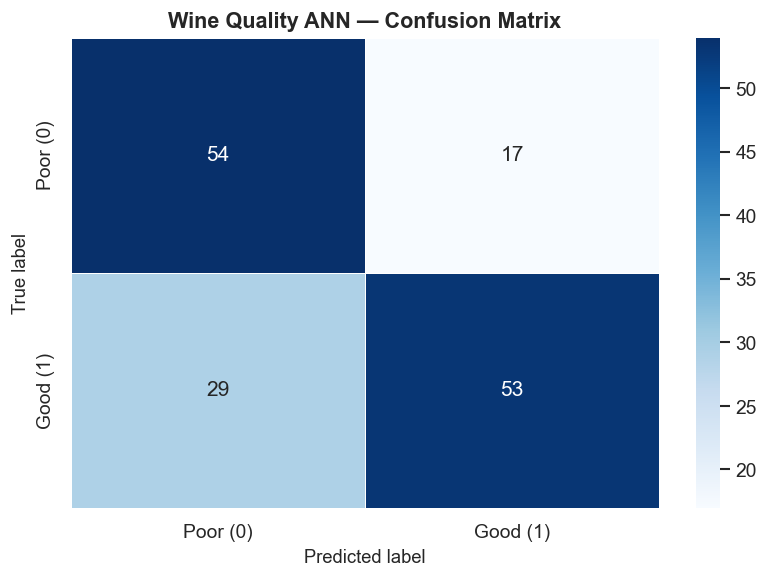

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/roc_curve.png


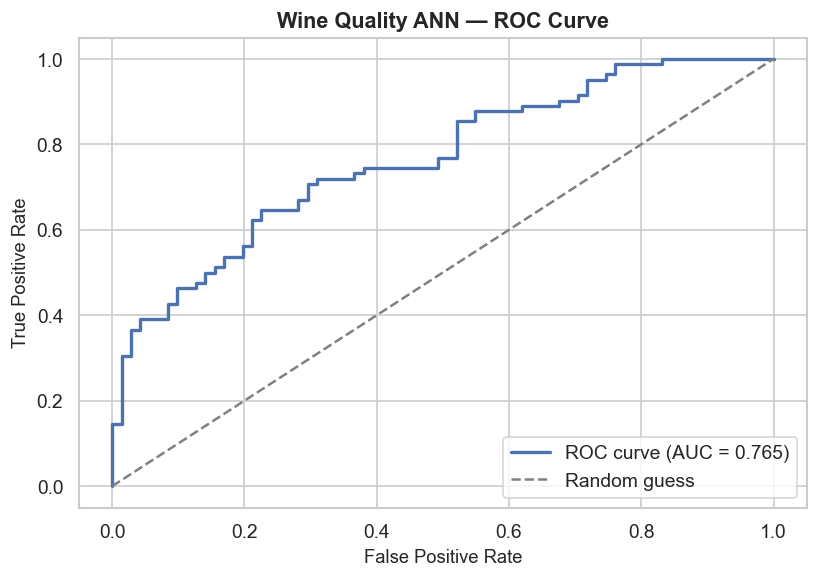

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/training_history.png


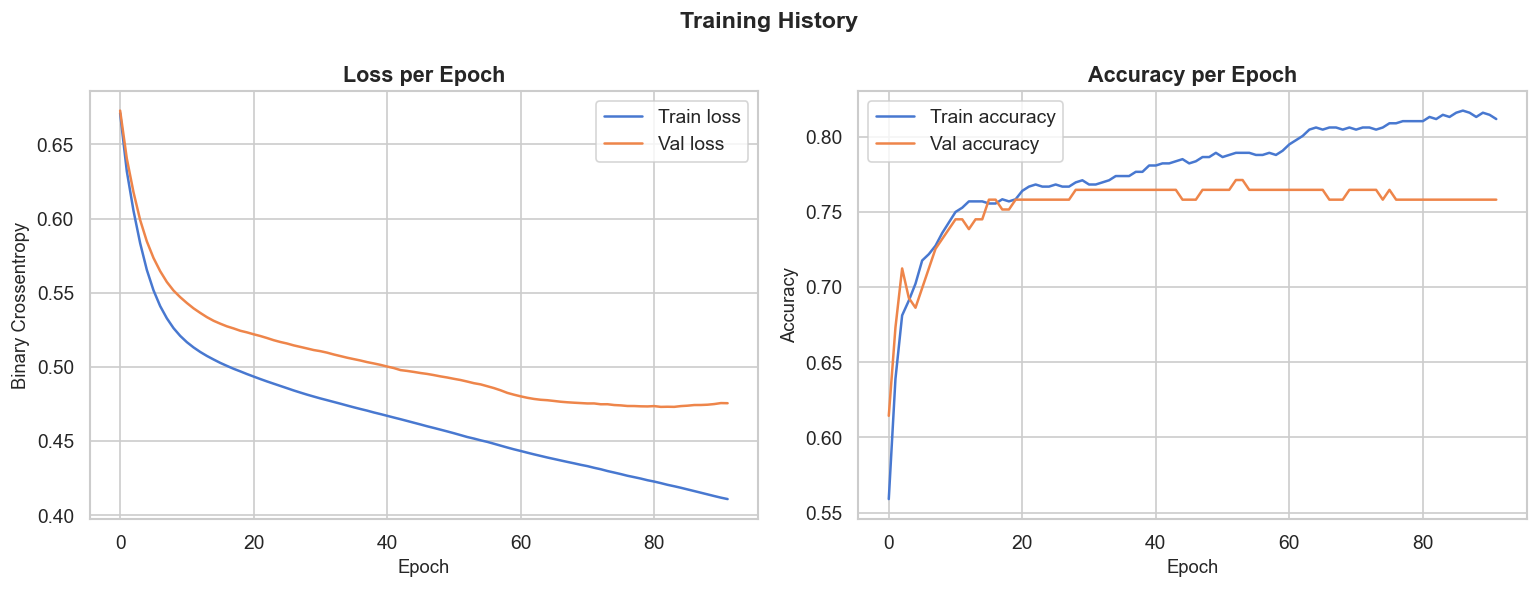

In [5]:
# ── Utvärdera modellen på testdata ────────────────────────
from src.evaluate import evaluate_model

evaluate_model(model, X_test_scaled, y_test, history)

## Tolkning av baseline-resultat

**Classification Report (testdata, 153 samples):**

| Klass | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| Poor (0) | 0.65 | 0.76 | 0.70 | 71 |
| Good (1) | 0.76 | 0.65 | 0.70 | 82 |
| **Accuracy** | | | **0.70** | 153 |

**Confusion Matrix:**

|  | Pred. Poor (0) | Pred. Good (1) |
|---|---|---|
| **True Poor (0)** | 54 (TN) | 17 (FP) |
| **True Good (1)** | 29 (FN) | 53 (TP) |

**ROC-kurva:** AUC = **0.765** — modellen särskiljer klasserna betydligt
bättre än slumpen (AUC 0.5), men det finns utrymme för förbättring.

**Training History:** Kurvorna bekräftar mönstret från cell 4 — träningsloss
fortsätter sjunka (~0.41) medan valideringsloss planar ut och till och med
vänder svagt uppåt efter ~epoch 60 (~0.475). Träningsaccuracy fortsätter
stiga (~0.81) medan valideringsaccuracy stagnerar runt ~0.76. Gapet mellan
kurvorna är en tydlig indikation på **begynnande overfitting**.

## Sammanfattning — Baseline-modell

| Metric | Värde |
|--------|-------|
| Test Accuracy | 0.70 |
| Test AUC | 0.765 |
| Träningsaccuracy (bäst) | ~0.81 |
| Valideringsaccuracy (bäst) | ~0.77 |

Modellen presterar **klart bättre än att alltid gissa majoritetsklassen**
(~54% om "Good" alltid gissas), men gapet mellan tränings- och
valideringskurvor visar att modellen börjar memorera träningsdatan snarare
än att generalisera. Detta är precis det problem som **L2-regularisering och
Dropout** (redan implementerat i `build_model()` i `src/model.py`) är avsedda
att lösa — vilket undersöks i Steg 4 (Grid Search-optimering).